In [1]:
import os
import random
import warnings

warnings.filterwarnings("ignore")

In [18]:
import numpy as np
import pandas as pd

import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import Input, Dense

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    TargetEncoder, # Ensure you are using sklearn >= 1.3
    OneHotEncoder
)

In [41]:
SEED = 42

def set_global_seed(seed=42):
    random.seed(seed)
    
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

    os.environ["TF_DETERMINISTIC_OPS"] = "1"
    os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    tf.random.set_seed(SEED)

    print(f"Global seed set to {seed}")

set_global_seed(SEED)

Global seed set to 42


In [4]:
# Load the dataset
data = pd.read_csv("D:\deep_learning\salary_dataset.csv")

# What type is this?
print(f"Type: {type(data)}")
print(f"Shape: {data.shape}  →  {data.shape[0]} rows, {data.shape[1]} columns")

Type: <class 'pandas.DataFrame'>
Shape: (30, 2)  →  30 rows, 2 columns


In [5]:
X = data.iloc[:, :-1].values    # All rows, all columns except last → Features
y = data.iloc[:, -1].values     # All rows, last column only → Target

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=SEED
)

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = Sequential([
    Input(shape=(1, )),
    Dense(units=1, activation='linear')
])

In [32]:
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01) , loss="mean_squared_error", metrics=["mae"])

In [33]:
history = model.fit(
    X_train_scaled,
    y_train, 
    epochs=200,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/200


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 28953228.0000 - mae: 4455.8633 - val_loss: 38482148.0000 - val_mae: 5199.9346
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 28952006.0000 - mae: 4455.6138 - val_loss: 38467376.0000 - val_mae: 5199.1621
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 28950820.0000 - mae: 4455.3677 - val_loss: 38452912.0000 - val_mae: 5198.4048
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 28949680.0000 - mae: 4455.1274 - val_loss: 38438820.0000 - val_mae: 5197.6641
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 28948602.0000 - mae: 4454.8921 - val_loss: 38425016.0000 - val_mae: 5196.9370
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 28947560.0000 - mae: 4454.6616 - val_loss: 38411496.0000 - val_mae: 5196.2241
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 28946548.0000 - mae: 4454.4336 - val_loss: 38398276.0000 - val_mae: 5195.5254
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - los

In [34]:
y_pred = model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


In [35]:
r2_score(y_test, y_pred)

0.9414284010526974

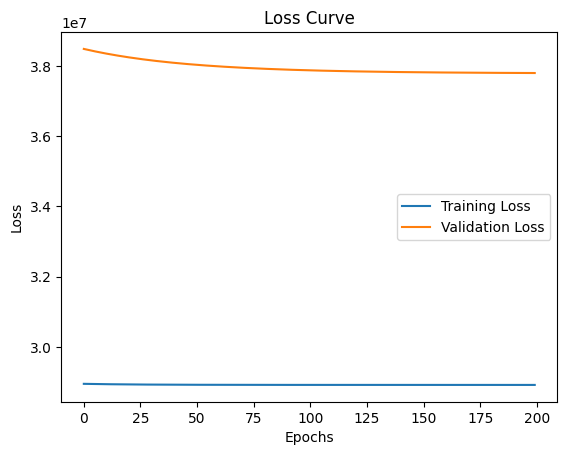

In [36]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

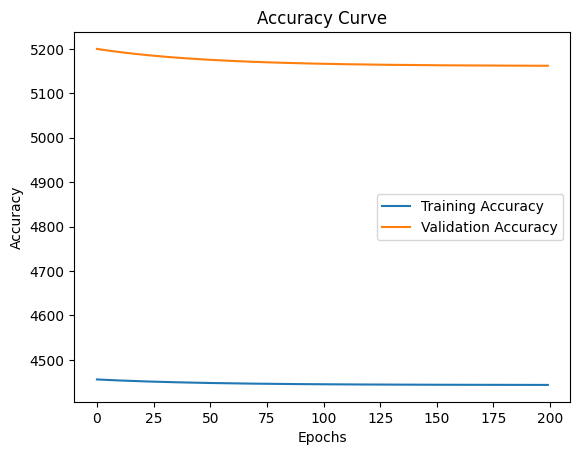

In [37]:
plt.plot(history.history['mae'], label='Training Accuracy')
plt.plot(history.history['val_mae'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

In [14]:
custom_input = np.array([[121872]])

In [15]:
custom_input_scaled = scaler.transform(custom_input)

In [16]:
prediction = model.predict(custom_input_scaled)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
[[9.872474e+08]]
